In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib import rcParams
import pandas as pd
import seaborn as sns
matplotlib_font_size=8
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Helvetica']
rcParams['font.size'] = 12
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'


path_figures=Path().cwd().parent.parent/"figures"
path_figures.mkdir(parents=True, exist_ok=True)
path_benchmark_data=Path.cwd().parent.parent/"benchmark_search_result"
path_benchmark_data.mkdir(parents=True, exist_ok=True)

In [2]:
query_size=100
ion_mode=[-1,1]


In [3]:
# parse txt
df=[]
data_rows=[]
for charge in ion_mode:
    search_result_file=path_benchmark_data/f'compare_search_result_query_{query_size}_charge_{charge}.txt'
    
    current_row=[]
    with open(search_result_file, 'r') as f:
        for line in f.readlines():
            items=line.split(":", maxsplit=1)
            key, value=items
            key=key.strip()
            value=value.strip()
            if key=="query_scan":
                if current_row and 'query_scan' in current_row:
                        data_rows.append(current_row)
                
                current_row={'charge':charge, 'query_scan':int(value)}
            elif key[-8:]=='max_diff':
                current_row[key]=float(value)
            else:
                continue

        if current_row and 'query_scan' in current_row:
            data_rows.append(current_row)

df = pd.DataFrame(data_rows)
df

,charge,query_scan,open_search_dynamic_all_build_max_diff,open_search_dynamic_build_update_1_max_diff,open_search_dynamic_build_update_2_max_diff,neutral_loss_search_dynamic_all_build_max_diff,neutral_loss_search_dynamic_build_update_1_max_diff,neutral_loss_search_dynamic_build_update_2_max_diff,hybrid_search_dynamic_all_build_max_diff,hybrid_search_dynamic_build_update_1_max_diff,hybrid_search_dynamic_build_update_2_max_diff
0,-1,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,-1,0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
2,-1,0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
3,-1,1,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,-1,1,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
595,1,98,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
596,1,98,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0
597,1,99,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
598,1,99,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN


In [ ]:
def plot_compare_search_result_max_diff(
        df,
        search_type,
        charge,
        ylim,
        save_path

):
    df_data = df[[f"{search_type}_search_dynamic_all_build_max_diff", 
              f"{search_type}_search_dynamic_build_update_1_max_diff",
              f"{search_type}_search_dynamic_build_update_2_max_diff", 
              'charge']]
    
    df_melted=df_data.melt(id_vars=["charge"], var_name="construction_type", value_name="max_diff")
    df_charge=df_melted[df_melted["charge"]==charge]

    hue_order=[f"{search_type}_search_dynamic_all_build_max_diff", f"{search_type}_search_dynamic_build_update_1_max_diff", f"{search_type}_search_dynamic_build_update_2_max_diff"]
    my_color_palette=['#3F4C8C', '#D7BC1F', "#E25D75"]

    color_palette={
    f"{search_type}_search_dynamic_all_build_max_diff": my_color_palette[0],
    f"{search_type}_search_dynamic_build_update_1_max_diff": my_color_palette[1],
    f"{search_type}_search_dynamic_build_update_2_max_diff": my_color_palette[2]}

    legend_labels = {
    
    f"{search_type}_search_dynamic_all_build_max_diff": 'Construct 1M from scratch', 
    f"{search_type}_search_dynamic_build_update_1_max_diff": 'Construct 0.1M from scratch\nand insert 0.9M in 1 batch',
    f"{search_type}_search_dynamic_build_update_2_max_diff": 'Construct 0.1M from scratch\nand insert 0.9M in 10 batches'
}
    # Plotting
    plt.figure(figsize=(6, 6))
    sns.stripplot(x='construction_type', y='max_diff', hue='construction_type', data=df_charge, legend=False, palette=color_palette)        
    sns.boxplot(data=df_charge, x='construction_type', y='max_diff', hue='construction_type', palette=color_palette,showfliers=False)
    
    bottom=ylim[0]
    top=ylim[1]
    plt.ylim(top=top, bottom=bottom)
    plt.title(f'Difference in similarity scores ({search_type.replace("_", " ")} search)')
    ax=plt.gca()
    ax.set_xlabel('')
    plt.ylabel('Maximum difference')
    new_labels =['Construct 1M from scratch', 
                'Construct 0.1M from scratch\nand insert 0.9M in 1 batch', 
                'Construct 0.1M from scratch\nand insert 0.9M in 10 batches']
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=15) 
    handles = []
    for method in hue_order:
        handle = plt.Line2D([0], [0], marker='o', color=color_palette[method], 
                       markersize=3, linestyle='',label=legend_labels.get(method, method))
        handles.append(handle)

    plt.legend(handles=handles, 
           loc='upper center', 
           bbox_to_anchor=(0.5, 1.3), 
           ncol=3, 
           fontsize=matplotlib_font_size,
           frameon=False)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0.1, dpi=1200)

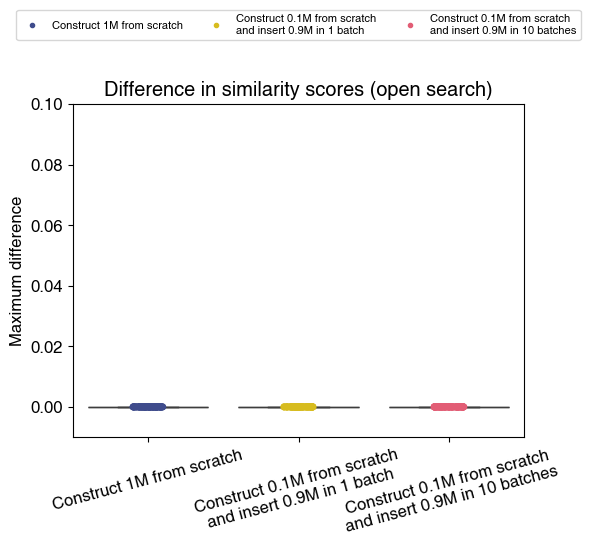

In [5]:
charge=-1
ylim=(-0.01,0.1)
search_type='open'
save_path=path_figures / f"compare_search_result_max_diff_charge_{charge}_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    charge=charge,
    ylim=ylim,
    save_path=save_path
)

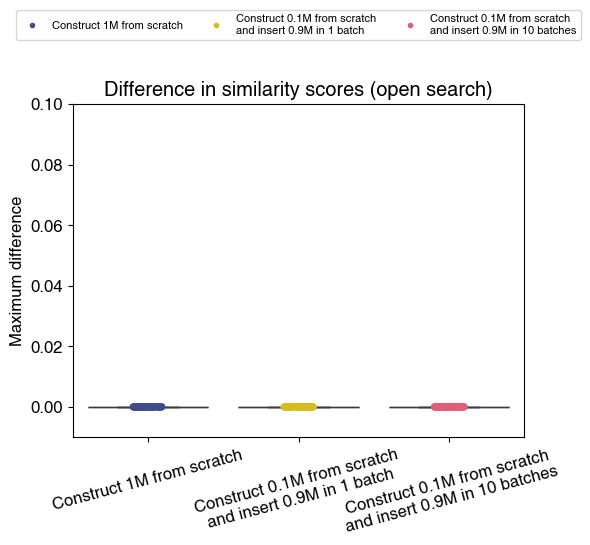

In [6]:
charge=1
ylim=(-0.01,0.1)
search_type='open'
save_path=path_figures / f"compare_search_result_max_diff_charge_{charge}_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    charge=charge,
    ylim=ylim,
    save_path=save_path
)

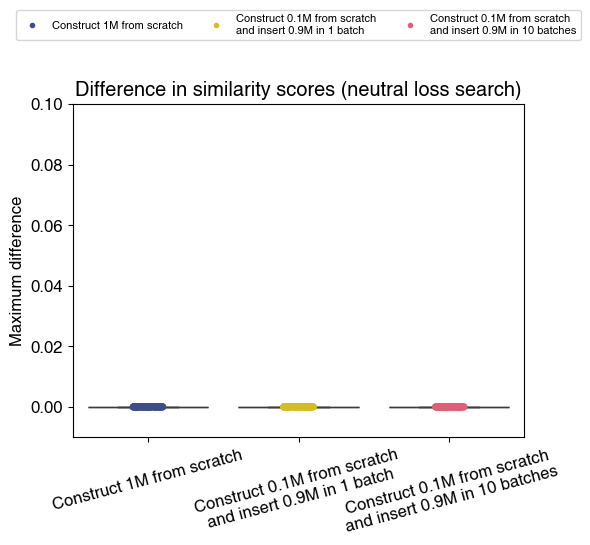

In [7]:
charge=-1
ylim=(-0.01,0.1)
search_type='neutral_loss'
save_path=path_figures / f"compare_search_result_max_diff_charge_{charge}_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    charge=charge,
    ylim=ylim,
    save_path=save_path
)

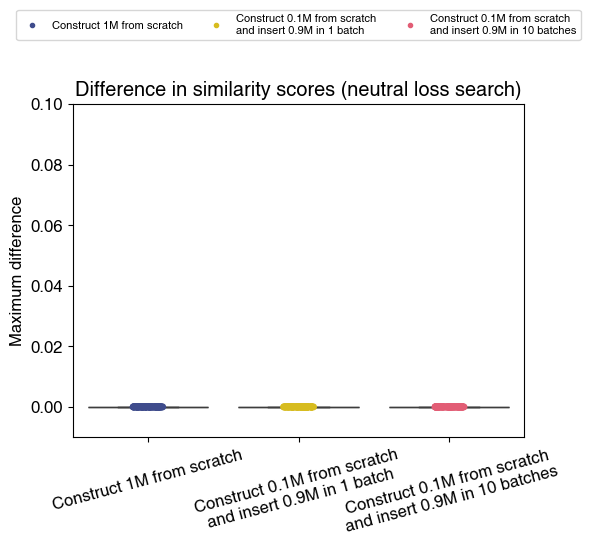

In [8]:
charge=1
ylim=(-0.01,0.1)
search_type='neutral_loss'
save_path=path_figures / f"compare_search_result_max_diff_charge_{charge}_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    charge=charge,
    ylim=ylim,
    save_path=save_path
)

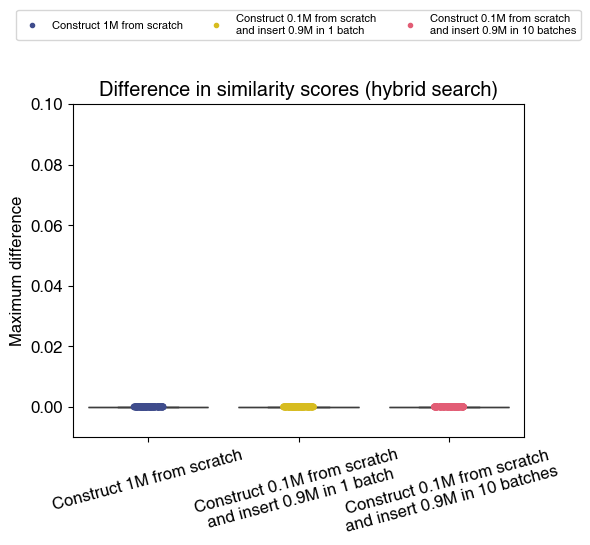

In [9]:
charge=-1
ylim=(-0.01,0.1)
search_type='hybrid'
save_path=path_figures / f"compare_search_result_max_diff_charge_{charge}_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    charge=charge,
    ylim=ylim,
    save_path=save_path
)

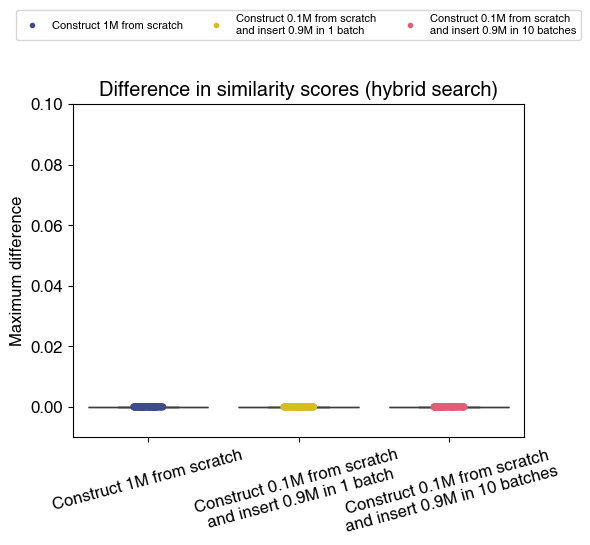

In [10]:
charge=1
ylim=(-0.01,0.1)
search_type='hybrid'
save_path=path_figures / f"compare_search_result_max_diff_charge_{charge}_{search_type}_search.svg"
plot_compare_search_result_max_diff(
    df=df,
    search_type=search_type,
    charge=charge,
    ylim=ylim,
    save_path=save_path
)